In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from pathlib import Path

pd.set_option("display.max_columns",100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

RAW_PATH = Path("/Users/erincheng/Desktop/media-analytics-mmm-lite/data/raw/media_facebook.csv")
CLEAN_PATH = Path("../data/processed/final_dataset.csv")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


Matplotlib is building the font cache; this may take a moment.


In [3]:
# load data
df = pd.read_csv(RAW_PATH)
df.head()

,date,channel,campaign,impressions,clicks,conversions,cost,revenue,cpc,cpa,ctr,conversion_rate,roas,roi,profit_margin
0,2023-11-01,Facebook,Best Sellers,75764,24390,3645,"27,534.3121","136,591.8130",1.1289,7.5540,0.3219,0.1494,4.9608,3.9608,0.7984
1,2023-11-01,Facebook,Exclusive Offers,79882,27362,3402,"28,207.7826","142,821.7795",1.0309,8.2915,0.3425,0.1243,5.0632,4.0632,0.8025
2,2023-11-01,Facebook,Flash Sale,82355,27350,4269,"28,519.9799","217,096.0091",1.0428,6.6807,0.3321,0.1561,7.6121,6.6121,0.8686
3,2023-11-01,Facebook,Limited Edition,59532,20314,2456,"22,405.3876","74,248.4349",1.1030,9.1227,0.3412,0.1209,3.3139,2.3139,0.6982
4,2023-11-01,Facebook,Must-Haves,76115,23283,4124,"30,655.0915","282,509.8398",1.3166,7.4333,0.3059,0.1771,9.2158,8.2158,0.8915


In [4]:
print(df.shape)
print(df.columns.tolist())
df.info()

(1274, 15)
['date', 'channel', 'campaign', 'impressions', 'clicks', 'conversions', 'cost', 'revenue', 'cpc', 'cpa', 'ctr', 'conversion_rate', 'roas', 'roi', 'profit_margin']
<class 'pandas.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             1274 non-null   str    
 1   channel          1274 non-null   str    
 2   campaign         1274 non-null   str    
 3   impressions      1274 non-null   int64  
 4   clicks           1274 non-null   int64  
 5   conversions      1274 non-null   int64  
 6   cost             1274 non-null   float64
 7   revenue          1274 non-null   float64
 8   cpc              1274 non-null   float64
 9   cpa              1274 non-null   float64
 10  ctr              1274 non-null   float64
 11  conversion_rate  1274 non-null   float64
 12  roas             1274 non-null   float64
 13  roi              1274 non-null   fl

In [ ]:
# standardize column names to snake case

def to_snake(col: str) -> str:
    col = col.strip().lower()
    for ch in [" ", "-", "/", "(", ")", "%"]:
        col = col.replace(ch, "_")
    while "__" in col:
        col = col.replace("__", "_")
    return col.strip("_")

df.columns = [to_snake(c) for c in df.columns]
df.columns.tolist()

['date',
 'channel',
 'campaign',
 'impressions',
 'clicks',
 'conversions',
 'cost',
 'revenue',
 'cpc',
 'cpa',
 'ctr',
 'conversion_rate',
 'roas',
 'roi',
 'profit_margin']

In [6]:
# parse dates

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# convert numeric fields

numeric_cols = [
    "impressions", "clicks", "conversions", "cost", "revenue", "cpc", "cpa", "ctr", "conversion_rate", "roas", "roi", "profit_margin"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors = "coerce")

df.info()





<class 'pandas.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             1274 non-null   datetime64[us]
 1   channel          1274 non-null   str           
 2   campaign         1274 non-null   str           
 3   impressions      1274 non-null   int64         
 4   clicks           1274 non-null   int64         
 5   conversions      1274 non-null   int64         
 6   cost             1274 non-null   float64       
 7   revenue          1274 non-null   float64       
 8   cpc              1274 non-null   float64       
 9   cpa              1274 non-null   float64       
 10  ctr              1274 non-null   float64       
 11  conversion_rate  1274 non-null   float64       
 12  roas             1274 non-null   float64       
 13  roi              1274 non-null   float64       
 14  profit_margin    1274 non-null   float64       
dty

In [7]:
# missing values by column
df.isna().sum().sort_values(ascending=False)

date               0
channel            0
campaign           0
impressions        0
clicks             0
conversions        0
cost               0
revenue            0
cpc                0
cpa                0
ctr                0
conversion_rate    0
roas               0
roi                0
profit_margin      0
dtype: int64

In [8]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
# quick stat overview
df.describe(include="all").T 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1274,NaN,NaN,NaN,2024-01-30 12:00:00,2023-11-01 00:00:00,2023-12-16 00:00:00,2024-01-30 12:00:00,2024-03-16 00:00:00,2024-04-30 00:00:00,NaN
channel,1274,1,Facebook,1274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,1274,7,Best Sellers,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
impressions,"1,274.0000",NaN,NaN,NaN,"62,789.5683","20,276.0000","53,069.7500","62,557.5000","72,158.7500","112,091.0000","14,722.4552"
clicks,"1,274.0000",NaN,NaN,NaN,"19,326.1484","5,225.0000","15,435.2500","18,969.5000","22,958.7500","37,072.0000","5,499.5001"
conversions,"1,274.0000",NaN,NaN,NaN,"2,334.9278",471.0000,"1,825.2500","2,236.5000","2,775.7500","5,262.0000",753.0786
cost,"1,274.0000",NaN,NaN,NaN,"24,519.8517","6,911.6991","18,912.3801","23,870.3030","29,307.1248","64,894.4343","7,729.8188"
revenue,"1,274.0000",NaN,NaN,NaN,"116,965.5703","19,329.0877","73,564.7968","106,928.0819","152,679.0118","360,625.8627","56,587.4580"
cpc,"1,274.0000",NaN,NaN,NaN,1.3122,0.4382,1.0702,1.2640,1.4983,3.6218,0.3923
cpa,"1,274.0000",NaN,NaN,NaN,11.1062,4.4516,8.3543,10.6158,12.8940,43.9618,3.9162


In [10]:
# remove duplicates and and impossible values

business_key = ["date","channel", "campaign"]
df = df.drop_duplicates(subset=business_key).copy()

# drop negtive or impossible volume/money values

for col in ["impressions", "clicks", "conversions", "cost", "revenue"]:
    df = df[df[col].fillna(0) >= 0]

df.shape

(1274, 15)

In [ ]:
# re calculate kpi to validate source material

def safe_div(num: pd.Series, den: pd.Series) -> pd.Series:
    return np.where((den.isna()) | (den == 0), np.nan, num / den)

df["cpc_calc"] = safe_div(df["cost"], df["clicks"])
df["cpa_calc"] = safe_div(df["cost"], df["conversions"])
df["ctr_calc"] = safe_div(df["clicks"], df["impressions"])
df["conversion_rate_calc"] = safe_div(df["conversions"], df["clicks"])
df["roas_calc"] = safe_div(df["revenue"], df["cost"])
df["roi_calc"] = safe_div(df["revenue"] - df["cost"], df["cost"])
df["profit_margin_calc"] = safe_div(df["revenue"] - df["cost"], df["revenue"])

df[
    [
        "cpc", "cpc_calc",
        "cpa", "cpa_calc",
        "ctr", "ctr_calc",
        "conversion_rate", "conversion_rate_calc",
        "roas", "roas_calc",
        "roi", "roi_calc",
        "profit_margin", "profit_margin_calc",
    ]
].head()

,cpc,cpc_calc,cpa,cpa_calc,ctr,ctr_calc,conversion_rate,conversion_rate_calc,roas,roas_calc,roi,roi_calc,profit_margin,profit_margin_calc
0,1.1289,1.1289,7.5540,7.5540,0.3219,0.3219,0.1494,0.1494,4.9608,4.9608,3.9608,3.9608,0.7984,0.7984
1,1.0309,1.0309,8.2915,8.2915,0.3425,0.3425,0.1243,0.1243,5.0632,5.0632,4.0632,4.0632,0.8025,0.8025
2,1.0428,1.0428,6.6807,6.6807,0.3321,0.3321,0.1561,0.1561,7.6121,7.6121,6.6121,6.6121,0.8686,0.8686
3,1.1030,1.1030,9.1227,9.1227,0.3412,0.3412,0.1209,0.1209,3.3139,3.3139,2.3139,2.3139,0.6982,0.6982
4,1.3166,1.3166,7.4333,7.4333,0.3059,0.3059,0.1771,0.1771,9.2158,9.2158,8.2158,8.2158,0.8915,0.8915


In [13]:
validation_summary = pd.DataFrame({
    "metric": ["cpc","cpa","ctr","conversion_rate","roas","roi", "profit_margin"],
    "avg_abs_dff": [
        (df["cpc"] - df["cpc_calc"]).abs().mean(),
        (df["cpa"] - df["cpa_calc"]).abs().mean(),
        (df["ctr"] - df["ctr_calc"]).abs().mean(),
        (df["conversion_rate"] - df["conversion_rate_calc"]).abs().mean(),
        (df["roas"] - df["roas_calc"]).abs().mean(),
        (df["roi"] - df["roi_calc"]).abs().mean(),
        (df["profit_margin"] - df["profit_margin_calc"]).abs().mean(),
    ]
})
validation_summary

,metric,avg_abs_dff
0,cpc,0.0000
1,cpa,0.0000
2,ctr,0.0000
3,conversion_rate,0.0000
4,roas,0.0000
5,roi,0.0000
6,profit_margin,0.0000


In [14]:
# drop rows missing key dimensions
df = df.dropna(subset=["date", "channel", "campaign"]).copy()

# fill metrics with 0 where needed
for col in ["impressions", "clicks", "conversions", "cost","revenue"]:
    df[col] = df[col].fillna(0)

df.isna().sum().sort_values(ascending=False).head(20)

date                    0
channel                 0
roi_calc                0
roas_calc               0
conversion_rate_calc    0
ctr_calc                0
cpa_calc                0
cpc_calc                0
profit_margin           0
roi                     0
roas                    0
conversion_rate         0
ctr                     0
cpa                     0
cpc                     0
revenue                 0
cost                    0
conversions             0
clicks                  0
impressions             0
dtype: int64

In [ ]:
# feature engineering (calendar and profit)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["quarter"] = df["date"].dt.to_period("Q").astype(str)
df["week_start"] = df["date"].dt.to_period("W").apply(lambda r: r.start_time)

df["profit"] = df["revenue"] - df["cost"]

df.head()

,date,channel,campaign,impressions,clicks,conversions,cost,revenue,cpc,cpa,ctr,conversion_rate,roas,roi,profit_margin,cpc_calc,cpa_calc,ctr_calc,conversion_rate_calc,roas_calc,roi_calc,profit_margin_calc,year,month,month_name,quarter,week_start,profit
0,2023-11-01,Facebook,Best Sellers,75764,24390,3645,"27,534.3121","136,591.8130",1.1289,7.5540,0.3219,0.1494,4.9608,3.9608,0.7984,1.1289,7.5540,0.3219,0.1494,4.9608,3.9608,0.7984,2023,11,November,2023Q4,2023-10-30,"109,057.5008"
1,2023-11-01,Facebook,Exclusive Offers,79882,27362,3402,"28,207.7826","142,821.7795",1.0309,8.2915,0.3425,0.1243,5.0632,4.0632,0.8025,1.0309,8.2915,0.3425,0.1243,5.0632,4.0632,0.8025,2023,11,November,2023Q4,2023-10-30,"114,613.9968"
2,2023-11-01,Facebook,Flash Sale,82355,27350,4269,"28,519.9799","217,096.0091",1.0428,6.6807,0.3321,0.1561,7.6121,6.6121,0.8686,1.0428,6.6807,0.3321,0.1561,7.6121,6.6121,0.8686,2023,11,November,2023Q4,2023-10-30,"188,576.0291"
3,2023-11-01,Facebook,Limited Edition,59532,20314,2456,"22,405.3876","74,248.4349",1.1030,9.1227,0.3412,0.1209,3.3139,2.3139,0.6982,1.1030,9.1227,0.3412,0.1209,3.3139,2.3139,0.6982,2023,11,November,2023Q4,2023-10-30,"51,843.0473"
4,2023-11-01,Facebook,Must-Haves,76115,23283,4124,"30,655.0915","282,509.8398",1.3166,7.4333,0.3059,0.1771,9.2158,8.2158,0.8915,1.3166,7.4333,0.3059,0.1771,9.2158,8.2158,0.8915,2023,11,November,2023Q4,2023-10-30,"251,854.7483"


In [16]:
# channel level eda

channel_summary = (
    df.groupby("channel", as_index=False)
      .agg(
          impressions=("impressions","sum"),
          clicks=("clicks","sum"),
          conversions=("conversions","sum"),
          cost=("cost","sum"),
          revenue=("revenue","sum"),
          profit=("profit","sum"),
      )
)

channel_summary["ctr"] = safe_div(channel_summary["clicks"], channel_summary["impressions"])
channel_summary["conversion_rate"] = safe_div(channel_summary["conversions"], channel_summary["clicks"])
channel_summary["cpc"] = safe_div(channel_summary["cost"], channel_summary["clicks"])
channel_summary["cpa"] = safe_div(channel_summary["cost"], channel_summary["conversions"])
channel_summary["roas"] = safe_div(channel_summary["revenue"], channel_summary["cost"])
channel_summary["roi"] = safe_div(channel_summary["profit"], channel_summary["cost"])

channel_summary.sort_values("roas", ascending=False)

,channel,impressions,clicks,conversions,cost,revenue,profit,ctr,conversion_rate,cpc,cpa,roas,roi
0,Facebook,79993910,24621513,2974698,"31,238,291.0055","149,014,136.5404","117,775,845.5349",0.3078,0.1208,1.2687,10.5013,4.7702,3.7702


/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_85502/936104672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_summary, x="channel", y="roas", order=order, palette="viridis")


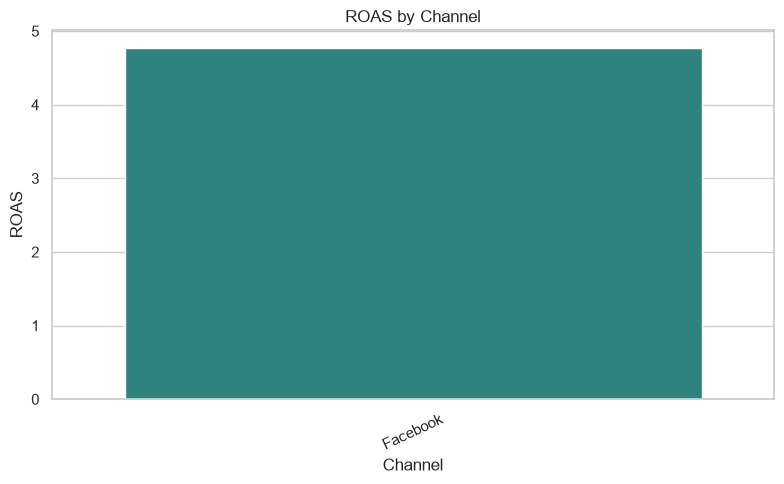

In [17]:
plt.figure(figsize=(8, 5))
order = channel_summary.sort_values("roas", ascending=False)["channel"]
sns.barplot(data=channel_summary, x="channel", y="roas", order=order, palette="viridis")
plt.title("ROAS by Channel")
plt.xlabel("Channel")
plt.ylabel("ROAS")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_DIR / "roas_by_channel.png", dpi=150)
plt.show()

In [18]:
# campaign level eda

campaign_summary = (
    df.groupby("campaign", as_index=False)
      .agg(
          cost=("cost","sum"),
          revenue=("revenue","sum"),
          conversions=("conversions","sum"),
          clicks=("clicks","sum"),
      )
)

campaign_summary["roas"] = safe_div(campaign_summary["revenue"], campaign_summary["cost"])
campaign_summary["conversion_rate"] = safe_div(campaign_summary["conversions"], campaign_summary["clicks"])

campaign_summary.sort_values("revenue", ascending=False)

,campaign,cost,revenue,conversions,clicks,roas,conversion_rate
0,Best Sellers,"5,346,108.2579","26,019,977.1383",510791,4237876,4.8671,0.1205
2,Flash Sale,"4,945,382.1416","24,687,901.5155",475114,3901175,4.9921,0.1218
4,Must-Haves,"4,753,320.7389","22,078,101.1278",452333,3729760,4.6448,0.1213
5,New Arrivals,"4,189,149.7696","20,189,678.5135",400647,3311466,4.8195,0.1210
3,Limited Edition,"4,442,766.6170","19,961,450.9620",421413,3486072,4.4930,0.1209
1,Exclusive Offers,"3,996,545.9680","18,622,342.8275",374187,3136484,4.6596,0.1193
6,Trending Now,"3,565,017.5124","17,454,684.4558",340213,2818680,4.8961,0.1207


/var/folders/3v/7tw8ds4112319zm34xbm40vr0000gn/T/ipykernel_85502/4170593749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_summary, x="campaign", y="revenue", order=order, palette="magma")


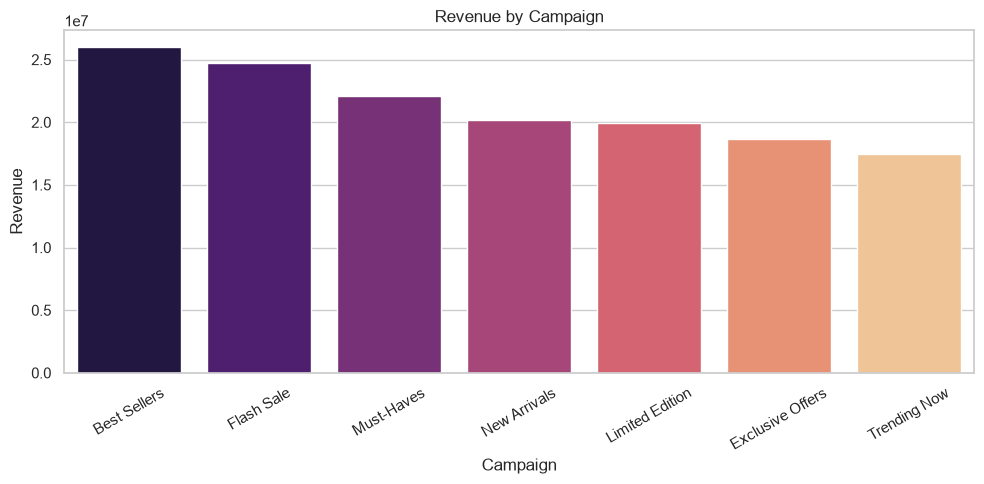

In [19]:
plt.figure(figsize=(10, 5))
order = campaign_summary.sort_values("revenue", ascending=False)["campaign"]
sns.barplot(data=campaign_summary, x="campaign", y="revenue", order=order, palette="magma")
plt.title("Revenue by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "revenue_by_campaign.png", dpi=150)
plt.show()

In [20]:
# time series EDA (daily cost vs. revenue)

daily_summary = (
    df.groupby("date", as_index=False)
      .agg(cost=("cost","sum"), revenue=("revenue","sum"), conversions=("conversions","sum"))
)

daily_summary.head()

,date,cost,revenue,conversions
0,2023-11-01,"174,356.9194","1,128,099.6372",22475
1,2023-11-02,"120,481.1282","522,257.2369",9603
2,2023-11-03,"167,741.8996","1,167,471.4101",21041
3,2023-11-04,"226,962.4162","634,352.6778",16811
4,2023-11-05,"187,042.8842","617,586.1321",14992


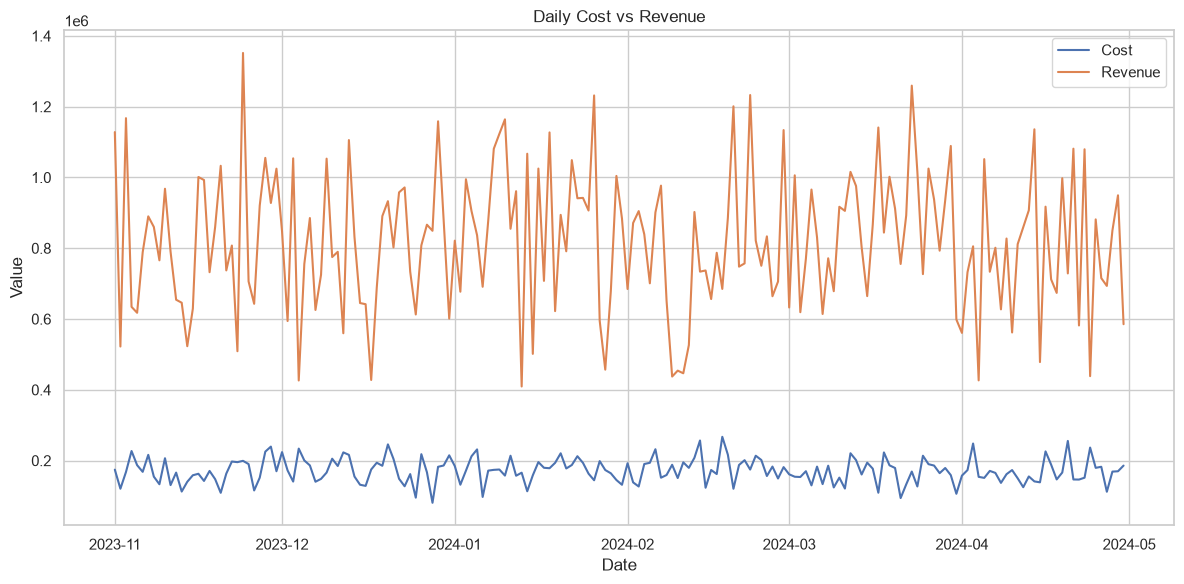

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_summary, x="date", y="cost", label="Cost")
sns.lineplot(data=daily_summary, x="date", y="revenue", label="Revenue")
plt.title("Daily Cost vs Revenue")
plt.xlabel("Date")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_cost_vs_revenue.png", dpi=150)
plt.show()

In [22]:
# outlier review

for metric in ["impressions","clicks","conversions","cost","revenue"]:
    q1 = df[metric].quantile(0.25)
    q3 = df[metric].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rate = ((df[metric] < lower) | (df[metric] > upper)).mean()
    print(metric, {"lower_bound": lower, "upper_bound": upper, "outlier_rate": round(outlier_rate, 4)})

impressions {'lower_bound': np.float64(24436.25), 'upper_bound': np.float64(100792.25), 'outlier_rate': np.float64(0.0086)}
clicks {'lower_bound': np.float64(4150.0), 'upper_bound': np.float64(34244.0), 'outlier_rate': np.float64(0.0047)}
conversions {'lower_bound': np.float64(399.5), 'upper_bound': np.float64(4201.5), 'outlier_rate': np.float64(0.0133)}
cost {'lower_bound': np.float64(3320.2629816763038), 'upper_bound': np.float64(44899.24184650027), 'outlier_rate': np.float64(0.011)}
revenue {'lower_bound': np.float64(-45106.52581080141), 'upper_bound': np.float64(271350.3344008784), 'outlier_rate': np.float64(0.011)}


In [ ]:
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEAN_PATH, index=False)
CLEAN_PATH